In [1]:
import pandas as pd
import glob
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
import math

### Does spatial information from a nearby buoy (44095) improve forecasting at the target station

In [2]:
na_vals = [99, 999, 9999, 99999]

def read_ndbc_stdmet(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        header = None
        for line in f:
            if line.startswith("#YY"):
                header = line.lstrip("#").strip().split()
                break
    if header is None:
        raise ValueError(f"Couldn't find #YY header in {path}")

    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=header,
        na_values=na_vals,
        engine="python",
    )
    return df

def build_station_df(station_prefix):
    files = sorted(glob.glob(f"{station_prefix}*.txt"))  
    dfs = [read_ndbc_stdmet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    # make datetime
    df = df.rename(columns={"YY":"year","MM":"month","DD":"day","hh":"hour","mm":"minute"})
    df["datetime"] = pd.to_datetime(df[["year","month","day","hour","minute"]], errors="coerce")
    df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()

    return df

target = build_station_df("41025h")   # target station
nbr    = build_station_df("44095h")   # nearby station


In [3]:
target_hr = target.resample("1H").mean()
nbr_hr    = nbr.resample("1H").mean()

C:\Users\attafuro\AppData\Local\Temp\ipykernel_80564\3150706141.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  target_hr = target.resample("1H").mean()
C:\Users\attafuro\AppData\Local\Temp\ipykernel_80564\3150706141.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  nbr_hr    = nbr.resample("1H").mean()


In [12]:
cols_keep = ["WVHT","APD","DPD","WSPD","GST","PRES","ATMP"] 

target_x = target_hr[cols_keep].add_suffix("_T")   # T = target station
nbr_x    = nbr_hr[cols_keep].add_suffix("_N")      # N = neighbor station

merged = target_x.join(nbr_x, how="inner")  # aligned timestamps only


In [13]:
merged.shape


(52584, 14)

In [7]:
heat_df = pd.concat(
    [
        target_hr[["WVHT", "APD"]].add_suffix("_T"),
        nbr_hr[["WVHT", "APD"]].add_suffix("_N")
    ],
    axis=1
).dropna()


In [8]:
corr_mat = heat_df.corr()
corr_mat


,WVHT_T,APD_T,WVHT_N,APD_N
WVHT_T,1.000000,0.486012,0.863664,0.411787
APD_T,0.486012,1.000000,0.490354,0.785547
WVHT_N,0.863664,0.490354,1.000000,0.507013
APD_N,0.411787,0.785547,0.507013,1.000000


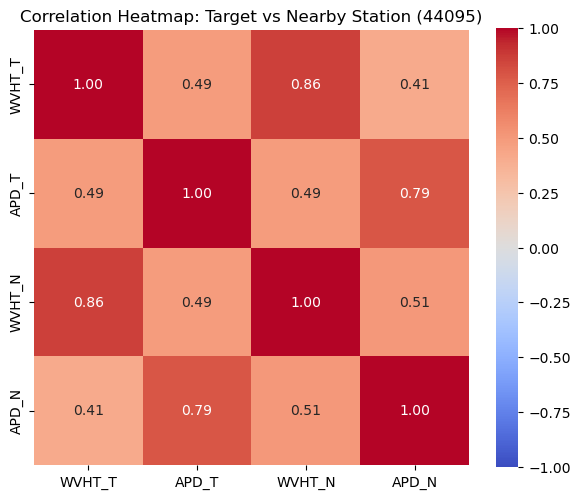

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation Heatmap: Target vs Nearby Station (44095)")
plt.tight_layout()
plt.show()


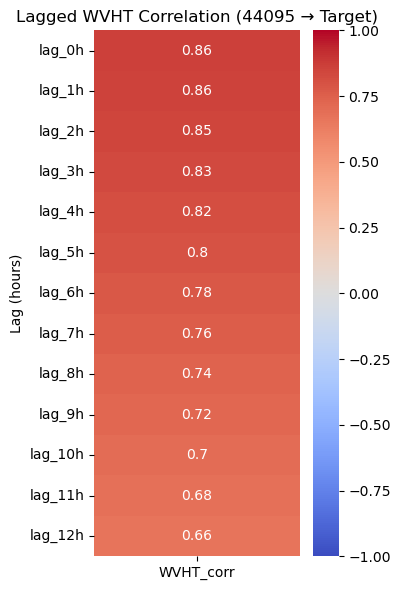

In [10]:
lags = range(0, 13)  # 0–12 hours
lag_corrs = {}

for lag in lags:
    lag_corrs[f"lag_{lag}h"] = heat_df["WVHT_T"].corr(
        heat_df["WVHT_N"].shift(lag)
    )

lag_df = pd.DataFrame.from_dict(lag_corrs, orient="index", columns=["WVHT_corr"])

plt.figure(figsize=(4,6))
sns.heatmap(lag_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Lagged WVHT Correlation (44095 → Target)")
plt.ylabel("Lag (hours)")
plt.tight_layout()
plt.show()


## Model Building 